In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

--- SEMILLA DORADA ENCONTRADA: 4 ---
Mejor Score de CV: 0.7133
Parámetros: {'selector__k': 1, 'tree__criterion': 'gini', 'tree__max_depth': 3}


Iniciando Shuffling Agresivo...
Cada shuffle buscará la mejor entre 100 semillas.
Shuffle 1/20 finalizado. Mejor score encontrado: 0.6733
Shuffle 2/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 3/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 4/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 5/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 6/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 7/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 8/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 9/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 10/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 11/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 12/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 13/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 14/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 15/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 16/20 finalizado. Mejor score encontrado: 0.6333
Shuffle 17/20 f

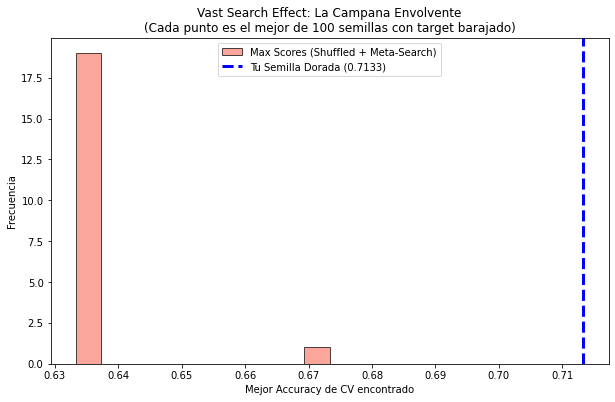

In [ ]:
n_samples = 150   # Menos muestras = más inestabilidad = scores más altos por azar
n_features = 2000  # Más características = más ruido = scores más altos por azar 

"""
--- Nueva mejor semilla encontrada: 7 con Score: 0.6000 ---
Parámetros del modelo : {'selector__k': 4, 'tree__criterion': 'gini', 'tree__max_depth': 5}
"""

seed, k, max_depth, criterion = (363, 1, None, 'gini')

np.random.seed(seed)
X = np.random.randn(n_samples, n_features)
y = np.random.randint(0, 2, n_samples)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
skb = SelectKBest(score_func=f_classif, k=k)
skb.fit(X_train, y_train)
X_train_selected = skb.transform(X_train)
X_test_selected = skb.transform(X_test)
model = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, random_state=seed)
model.fit(X_train_selected, y_train)
print(f"Score del modelo con semilla {seed}: {model.score(X_test_selected, y_test):.4f}")


Score del modelo con semilla 363: 0.7000
